
# Model Interpretability

## Credit Risk Intelligence Lab

This notebook adds an interpretability layer to the supervised probability of default model.

The previous notebooks built three analytical views of the credit portfolio: a supervised Probability of Default model, an unsupervised risk segmentation layer, and an anomaly detection layer. This notebook focuses on the question that matters once a model produces a score: **why did the model estimate this level of credit risk?**

In credit risk, interpretability is not optional. A model should not only rank borrowers by estimated risk; it should also provide readable evidence about the variables and borrower characteristics that drive the estimate.



## Notebook objectives

This notebook focuses on:

1. Loading the trained baseline PD model and processed datasets.
2. Inspecting global logistic regression coefficients.
3. Translating coefficients into directional risk signals.
4. Estimating permutation importance on the test sample.
5. Building local borrower-level explanations using log-odds contributions.
6. Comparing explanations across high-risk, low-risk, anomalous, and segmented borrowers.
7. Creating readable interpretation tables for reporting.
8. Saving interpretability outputs for the README, reports, and future dashboard.

The objective is not to claim causality. The objective is to explain how the model uses the available features to estimate credit risk.


In [1]:

from pathlib import Path
import warnings
import pickle
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")



## Project paths

The notebook is designed to run either from the project root or from the `notebooks/` directory.


In [2]:

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_FIGURES = PROJECT_ROOT / "reports" / "figures"
REPORTS_TABLES = PROJECT_ROOT / "reports" / "tables"

for path in [DATA_PROCESSED, MODELS_DIR, REPORTS_FIGURES, REPORTS_TABLES]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data path: {DATA_PROCESSED}")
print(f"Models path: {MODELS_DIR}")
print(f"Figures path: {REPORTS_FIGURES}")
print(f"Tables path: {REPORTS_TABLES}")


Project root: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab
Processed data path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed
Models path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/models
Figures path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/figures
Tables path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/tables



## Load model, processed data, and portfolio outputs

This notebook expects outputs from notebooks 02 and 03. Optional outputs from notebooks 04 and 05 are also loaded when available.


In [3]:

required_files = {
    "baseline_pd_model": MODELS_DIR / "baseline_logistic_pd_model.pkl",
    "X_train_processed": DATA_PROCESSED / "X_train_processed.csv",
    "X_test_processed": DATA_PROCESSED / "X_test_processed.csv",
    "y_train": DATA_PROCESSED / "y_train.csv",
    "y_test": DATA_PROCESSED / "y_test.csv",
    "X_train_raw": DATA_PROCESSED / "X_train.csv",
    "X_test_raw": DATA_PROCESSED / "X_test.csv",
}

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing files: "
        + ", ".join(missing_files)
        + ". Run notebooks 02 and 03 before this notebook."
    )

with open(required_files["baseline_pd_model"], "rb") as f:
    baseline_pd_model = pickle.load(f)

X_train = pd.read_csv(required_files["X_train_processed"], index_col=0)
X_test = pd.read_csv(required_files["X_test_processed"], index_col=0)

y_train = pd.read_csv(required_files["y_train"], index_col=0).iloc[:, 0]
y_test = pd.read_csv(required_files["y_test"], index_col=0).iloc[:, 0]

X_train_raw = pd.read_csv(required_files["X_train_raw"], index_col=0)
X_test_raw = pd.read_csv(required_files["X_test_raw"], index_col=0)

print(f"X_train processed: {X_train.shape}")
print(f"X_test processed: {X_test.shape}")
print(f"X_train raw: {X_train_raw.shape}")
print(f"X_test raw: {X_test_raw.shape}")


X_train processed: (800, 79)
X_test processed: (200, 79)
X_train raw: (800, 29)
X_test raw: (200, 29)


In [4]:

segments_file = DATA_PROCESSED / "credit_risk_segments.csv"
anomaly_file = DATA_PROCESSED / "credit_risk_anomaly_scores.csv"

segments = None
anomalies = None

if segments_file.exists():
    segments = pd.read_csv(segments_file, index_col=0)
    print(f"Loaded segment file: {segments.shape}")

if anomaly_file.exists():
    anomalies = pd.read_csv(anomaly_file, index_col=0)
    print(f"Loaded anomaly file: {anomalies.shape}")
    

Loaded segment file: (1000, 35)
Loaded anomaly file: (1000, 14)



## Recalculate model predictions

We recalculate predicted probabilities to ensure that the interpretability outputs are tied directly to the loaded model.


In [5]:

train_pd = baseline_pd_model.predict_proba(X_train)[:, 1]
test_pd = baseline_pd_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_pd)
test_auc = roc_auc_score(y_test, test_pd)

model_performance_snapshot = pd.DataFrame(
    {
        "sample": ["train", "test"],
        "roc_auc": [train_auc, test_auc],
        "average_pd": [train_pd.mean(), test_pd.mean()],
        "observed_default_rate": [y_train.mean(), y_test.mean()],
    }
)

model_performance_snapshot


,sample,roc_auc,average_pd,observed_default_rate
0,train,0.8482,0.4292,0.3000
1,test,0.7965,0.4427,0.3000



## Global coefficient interpretation

Logistic regression estimates the log-odds of default:

```text
logit(PD) = intercept + β₁x₁ + β₂x₂ + ... + βₙxₙ
```

A positive coefficient increases the estimated log-odds of default. A negative coefficient decreases the estimated log-odds of default. Since the processed dataset contains scaled numerical variables and one-hot encoded categorical variables, coefficients are best understood as directional model signals, not causal effects.


In [6]:

coefficients = pd.DataFrame(
    {
        "feature": X_train.columns,
        "coefficient": baseline_pd_model.coef_[0],
    }
)

coefficients["absolute_coefficient"] = coefficients["coefficient"].abs()
coefficients["odds_ratio"] = np.exp(coefficients["coefficient"])
coefficients["risk_direction"] = np.where(
    coefficients["coefficient"] > 0,
    "higher_estimated_default_risk",
    "lower_estimated_default_risk",
)

coefficients_sorted = coefficients.sort_values("absolute_coefficient", ascending=False)

coefficients_sorted.head(20)


,feature,coefficient,absolute_coefficient,odds_ratio,risk_direction
16,checking_account_status_A14,-0.9918,0.9918,0.3709,lower_estimated_default_risk
29,purpose_A46,0.9821,0.9821,2.6702,higher_estimated_default_risk
23,purpose_A41,-0.9192,0.9192,0.3988,lower_estimated_default_risk
21,credit_history_A34,-0.8767,0.8767,0.4162,lower_estimated_default_risk
76,credit_amount_bucket_low_amount,0.7693,0.7693,2.1582,higher_estimated_default_risk
77,credit_amount_bucket_medium_high_amount,-0.7490,0.7490,0.4728,lower_estimated_default_risk
13,checking_account_status_A11,0.6982,0.6982,2.0102,higher_estimated_default_risk
17,credit_history_A30,0.6933,0.6933,2.0003,higher_estimated_default_risk
66,foreign_worker_A202,-0.6666,0.6666,0.5134,lower_estimated_default_risk
65,foreign_worker_A201,0.6505,0.6505,1.9166,higher_estimated_default_risk



## Highest-risk and lowest-risk model signals

The next tables separate features associated with higher estimated default risk from features associated with lower estimated default risk.


In [7]:

top_higher_risk_signals = (
    coefficients
    .sort_values("coefficient", ascending=False)
    .head(20)
)

top_lower_risk_signals = (
    coefficients
    .sort_values("coefficient", ascending=True)
    .head(20)
)

top_higher_risk_signals


,feature,coefficient,absolute_coefficient,odds_ratio,risk_direction
29,purpose_A46,0.9821,0.9821,2.6702,higher_estimated_default_risk
76,credit_amount_bucket_low_amount,0.7693,0.7693,2.1582,higher_estimated_default_risk
13,checking_account_status_A11,0.6982,0.6982,2.0102,higher_estimated_default_risk
17,credit_history_A30,0.6933,0.6933,2.0003,higher_estimated_default_risk
65,foreign_worker_A201,0.6505,0.6505,1.9166,higher_estimated_default_risk
52,property_A124,0.6242,0.6242,1.8667,higher_estimated_default_risk
32,savings_account_A61,0.5766,0.5766,1.7799,higher_estimated_default_risk
42,personal_status_sex_A91,0.5259,0.5259,1.6919,higher_estimated_default_risk
53,other_installment_plans_A141,0.5252,0.5252,1.6908,higher_estimated_default_risk
28,purpose_A45,0.5024,0.5024,1.6526,higher_estimated_default_risk


In [8]:
top_lower_risk_signals

,feature,coefficient,absolute_coefficient,odds_ratio,risk_direction
16,checking_account_status_A14,-0.9918,0.9918,0.3709,lower_estimated_default_risk
23,purpose_A41,-0.9192,0.9192,0.3988,lower_estimated_default_risk
21,credit_history_A34,-0.8767,0.8767,0.4162,lower_estimated_default_risk
77,credit_amount_bucket_medium_high_amount,-0.7490,0.7490,0.4728,lower_estimated_default_risk
66,foreign_worker_A202,-0.6666,0.6666,0.5134,lower_estimated_default_risk
35,savings_account_A64,-0.6218,0.6218,0.5370,lower_estimated_default_risk
74,duration_bucket_very_long_term,-0.6103,0.6103,0.5432,lower_estimated_default_risk
40,employment_since_A74,-0.5569,0.5569,0.5730,lower_estimated_default_risk
24,purpose_A410,-0.5272,0.5272,0.5903,lower_estimated_default_risk
58,housing_A153,-0.4966,0.4966,0.6086,lower_estimated_default_risk


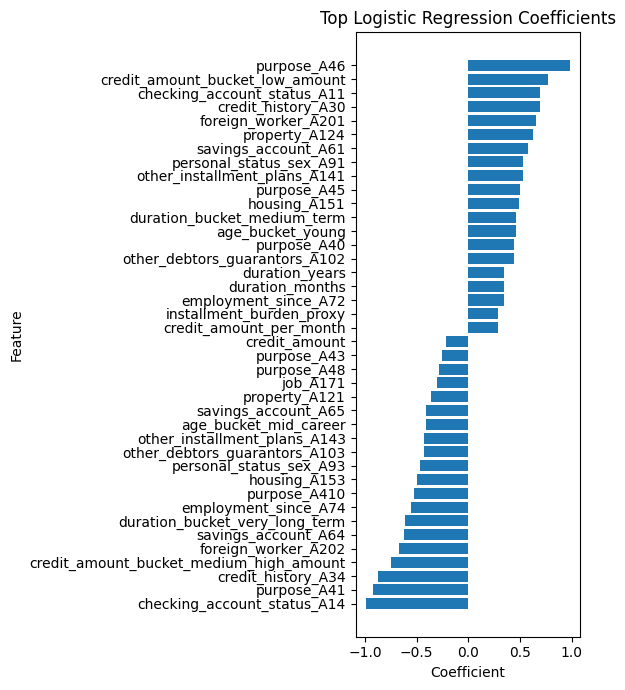

In [20]:

top_coefficients_for_plot = pd.concat(
    [
        top_higher_risk_signals.assign(signal_type="higher_risk"),
        top_lower_risk_signals.assign(signal_type="lower_risk"),
    ],
    axis=0,
).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(6, 7))

ax.barh(
    top_coefficients_for_plot["feature"],
    top_coefficients_for_plot["coefficient"],
)

ax.set_title("Top Logistic Regression Coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "06_top_logistic_coefficients.png", dpi=150)
plt.show();



## Feature family interpretation

Processed feature names often contain one-hot encoded categories. To make interpretation more readable, we group features into approximate families.


In [11]:

feature_families = [
    "checking_account_status",
    "credit_history",
    "purpose",
    "savings_account",
    "employment_since",
    "personal_status_sex",
    "other_debtors_guarantors",
    "property",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker",
    "age_bucket",
    "duration_bucket",
    "credit_amount_bucket",
    "credit_amount",
    "duration",
    "age",
    "installment",
    "existing_credits",
    "people_liable",
]

def assign_feature_family(feature_name: str) -> str:
    for family in feature_families:
        if feature_name.startswith(family) or family in feature_name:
            return family
    return "other"

coefficients["feature_family"] = coefficients["feature"].apply(assign_feature_family)

family_importance = (
    coefficients
    .groupby("feature_family")
    .agg(
        n_features=("feature", "size"),
        total_abs_coefficient=("absolute_coefficient", "sum"),
        avg_abs_coefficient=("absolute_coefficient", "mean"),
        avg_coefficient=("coefficient", "mean"),
    )
    .sort_values("total_abs_coefficient", ascending=False)
)

family_importance


,n_features,total_abs_coefficient,avg_abs_coefficient,avg_coefficient
feature_family,,,,
purpose,10,4.2746,0.4275,-0.0016
savings_account,5,2.0450,0.4090,-0.0032
checking_account_status,4,1.9676,0.4919,-0.0040
credit_history,5,1.9391,0.3878,-0.0032
credit_amount_bucket,4,1.5546,0.3886,-0.0040
foreign_worker,2,1.3172,0.6586,-0.0080
property,4,1.2644,0.3161,-0.0040
employment_since,5,1.2286,0.2457,-0.0032
duration_bucket,4,1.2045,0.3011,-0.0040


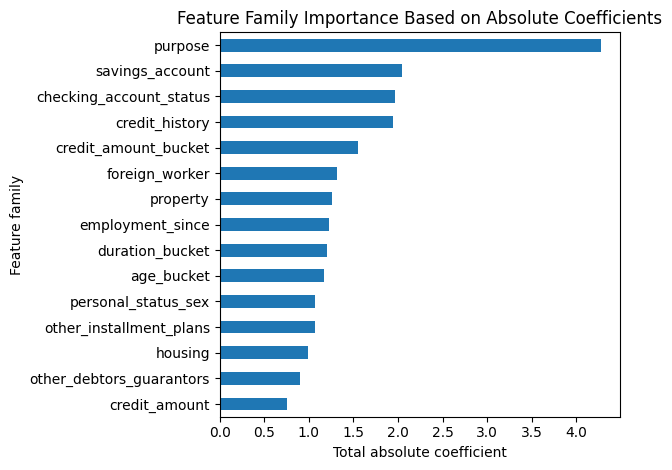

In [12]:

fig, ax = plt.subplots()

family_importance["total_abs_coefficient"].head(15).sort_values().plot(kind="barh", ax=ax)

ax.set_title("Feature Family Importance Based on Absolute Coefficients")
ax.set_xlabel("Total absolute coefficient")
ax.set_ylabel("Feature family")

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "06_feature_family_importance.png", dpi=150)
plt.show();



## Permutation importance

Coefficient magnitude is useful for interpreting a logistic regression model, but it does not fully measure predictive contribution.

Permutation importance evaluates how much model performance deteriorates when a feature is randomly shuffled. Here, we use ROC-AUC as the scoring metric on the test sample.


In [13]:

permutation_result = permutation_importance(
    baseline_pd_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

permutation_importance_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

permutation_importance_df.head(20)


,feature,importance_mean,importance_std
16,checking_account_status_A14,0.0356,0.0154
7,credit_amount_per_month,0.0260,0.0088
0,duration_months,0.0257,0.0067
9,duration_years,0.0257,0.0067
13,checking_account_status_A11,0.0184,0.0089
21,credit_history_A34,0.0167,0.0115
22,purpose_A40,0.0154,0.0037
23,purpose_A41,0.0136,0.0056
76,credit_amount_bucket_low_amount,0.0129,0.0070
77,credit_amount_bucket_medium_high_amount,0.0097,0.0090


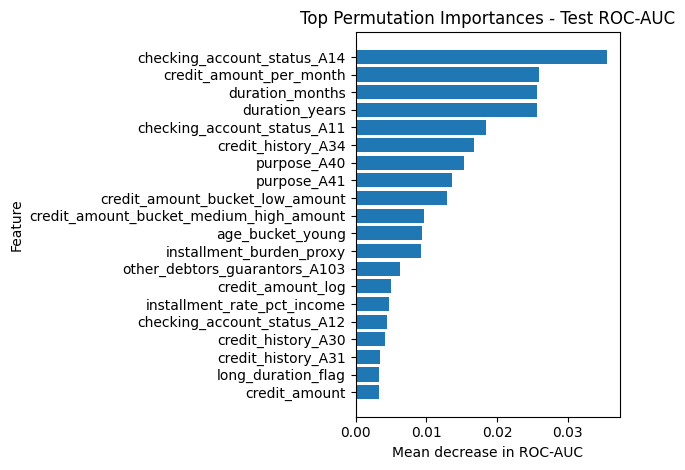

In [14]:

fig, ax = plt.subplots()

plot_perm = permutation_importance_df.head(20).sort_values("importance_mean")

ax.barh(plot_perm["feature"], plot_perm["importance_mean"])

ax.set_title("Top Permutation Importances - Test ROC-AUC")
ax.set_xlabel("Mean decrease in ROC-AUC")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "06_permutation_importance.png", dpi=150)
plt.show();



## Local explanation framework

For logistic regression, local explanations can be built directly from the log-odds equation.

For a given borrower:

```text
local contribution of feature j = xⱼ × βⱼ
```

The sum of all local contributions plus the intercept gives the log-odds of default. This can then be transformed into a probability.


In [21]:

intercept = baseline_pd_model.intercept_[0]
coef_vector = baseline_pd_model.coef_[0]

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def explain_single_observation(processed_row: pd.Series, top_n: int = 10) -> tuple:
    contributions = processed_row.values * coef_vector

    explanation = pd.DataFrame(
        {
            "feature": processed_row.index,
            "processed_value": processed_row.values,
            "coefficient": coef_vector,
            "log_odds_contribution": contributions,
        }
    )

    explanation["absolute_contribution"] = explanation["log_odds_contribution"].abs()
    explanation["direction"] = np.where(
        explanation["log_odds_contribution"] > 0,
        "pushes_PD_up",
        "pushes_PD_down",
    )

    log_odds = intercept + contributions.sum()
    pd_estimate = sigmoid(log_odds)

    top_explanation = explanation.sort_values("absolute_contribution", ascending=False).head(top_n)

    return top_explanation, log_odds, pd_estimate

sample_explanation, sample_log_odds, sample_pd_estimate = explain_single_observation(X_test.iloc[0], top_n=10)

print(f"Local log-odds: {sample_log_odds:.4f}")
print(f"Local PD estimate: {sample_pd_estimate:.4f}")
print(f"Model PD estimate: {test_pd[0]:.4f}")

sample_explanation


Local log-odds: -0.5441
Local PD estimate: 0.3672
Model PD estimate: 0.3672


,feature,processed_value,coefficient,log_odds_contribution,absolute_contribution,direction
65,foreign_worker_A201,1.0000,0.6505,0.6505,0.6505,pushes_PD_up
35,savings_account_A64,1.0000,-0.6218,-0.6218,0.6218,pushes_PD_down
53,other_installment_plans_A141,1.0000,0.5252,0.5252,0.5252,pushes_PD_up
72,duration_bucket_medium_term,1.0000,0.4626,0.4626,0.4626,pushes_PD_up
68,age_bucket_mid_career,1.0000,-0.4089,-0.4089,0.4089,pushes_PD_down
49,property_A121,1.0000,-0.3580,-0.3580,0.3580,pushes_PD_down
38,employment_since_A72,1.0000,0.3412,0.3412,0.3412,pushes_PD_up
14,checking_account_status_A12,1.0000,0.2370,0.2370,0.2370,pushes_PD_up
64,telephone_A192,1.0000,-0.1818,-0.1818,0.1818,pushes_PD_down
7,credit_amount_per_month,-0.4835,0.2858,-0.1382,0.1382,pushes_PD_down



## Build local explanation portfolio

This section creates borrower-level summaries of the strongest positive and negative model contributions.


In [22]:

def summarize_local_explanation(processed_row: pd.Series, top_n: int = 5) -> dict:
    explanation, log_odds, pd_estimate = explain_single_observation(processed_row, top_n=len(processed_row))

    top_positive = (
        explanation
        .sort_values("log_odds_contribution", ascending=False)
        .head(top_n)
        [["feature", "log_odds_contribution"]]
    )

    top_negative = (
        explanation
        .sort_values("log_odds_contribution", ascending=True)
        .head(top_n)
        [["feature", "log_odds_contribution"]]
    )

    positive_text = "; ".join(
        f"{row.feature} ({row.log_odds_contribution:.3f})"
        for row in top_positive.itertuples(index=False)
    )

    negative_text = "; ".join(
        f"{row.feature} ({row.log_odds_contribution:.3f})"
        for row in top_negative.itertuples(index=False)
    )

    return {
        "local_log_odds": log_odds,
        "local_pd": pd_estimate,
        "top_positive_contributors": positive_text,
        "top_negative_contributors": negative_text,
    }

local_explanations = []

for borrower_id, row in X_test.iterrows():
    explanation_summary = summarize_local_explanation(row, top_n=5)
    explanation_summary["borrower_id"] = borrower_id
    local_explanations.append(explanation_summary)

local_explanations_df = pd.DataFrame(local_explanations).set_index("borrower_id")

local_explanations_df.head()


,local_log_odds,local_pd,top_positive_contributors,top_negative_contributors
borrower_id,,,,
30,-0.5441,0.3672,foreign_worker_A201 (0.651); other_installment...,savings_account_A64 (-0.622); age_bucket_mid_c...
128,-2.0735,0.1117,foreign_worker_A201 (0.651); savings_account_A...,purpose_A41 (-0.919); credit_history_A34 (-0.8...
289,1.7155,0.8476,credit_amount_bucket_low_amount (0.769); check...,age_bucket_mid_career (-0.409); property_A121 ...
216,0.8112,0.6924,checking_account_status_A11 (0.698); credit_hi...,credit_amount_bucket_medium_high_amount (-0.74...
966,-1.3282,0.2095,foreign_worker_A201 (0.651); age_bucket_young ...,credit_history_A34 (-0.877); credit_amount_buc...



## Combine local explanations with raw borrower information

The local explanation table is more useful when combined with raw borrower characteristics, actual default outcome, predicted PD, risk cluster, and anomaly score.


In [23]:

test_interpretability = X_test_raw.copy()
test_interpretability.index = test_interpretability.index.astype(str)
y_test.index = y_test.index.astype(str)

test_interpretability["actual_default"] = y_test
test_interpretability["predicted_pd"] = test_pd

local_explanations_df.index = local_explanations_df.index.astype(str)
test_interpretability = test_interpretability.join(local_explanations_df, how="left")

if segments is not None:
    segments.index = segments.index.astype(str)
    segment_cols = [col for col in ["risk_cluster", "expected_loss_proxy"] if col in segments.columns]
    if segment_cols:
        test_interpretability = test_interpretability.join(
            segments[segment_cols],
            how="left",
            rsuffix="_segment",
        )

if anomalies is not None:
    anomalies.index = anomalies.index.astype(str)
    anomaly_cols = [
        col for col in [
            "ensemble_anomaly_score",
            "ensemble_anomaly_flag",
            "if_score_scaled",
            "lof_score_scaled",
        ]
        if col in anomalies.columns
    ]
    if anomaly_cols:
        test_interpretability = test_interpretability.join(
            anomalies[anomaly_cols],
            how="left",
            rsuffix="_anomaly",
        )

test_interpretability.head()


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_amount_per_month,credit_amount_log,duration_years,long_duration_flag,high_credit_amount_flag,installment_burden_proxy,age_bucket,duration_bucket,credit_amount_bucket,actual_default,predicted_pd,local_log_odds,local_pd,top_positive_contributors,top_negative_contributors,risk_cluster,expected_loss_proxy,ensemble_anomaly_score,ensemble_anomaly_flag,if_score_scaled,lof_score_scaled
30,A12,18,A32,A49,1913,A64,A72,3,A94,A101,3,A121,36,A141,A152,1,A173,1,A192,A201,106.2778,7.5570,1.5000,0,0,5739,mid_career,medium_term,medium_low_amount,0,0.3672,-0.5441,0.3672,foreign_worker_A201 (0.651); other_installment...,savings_account_A64 (-0.622); age_bucket_mid_c...,0,316.1313,0.2460,0,0.4671,0.0249
128,A12,12,A34,A41,1860,A61,A71,4,A93,A101,2,A123,34,A143,A152,2,A174,1,A192,A201,155.0000,7.5289,1.0000,0,0,7440,early_career,short_term,medium_low_amount,0,0.1117,-2.0735,0.1117,foreign_worker_A201 (0.651); savings_account_A...,purpose_A41 (-0.919); credit_history_A34 (-0.8...,0,93.4931,0.1373,0,0.2551,0.0196
289,A11,24,A33,A43,1024,A61,A72,4,A94,A101,4,A121,48,A142,A152,1,A173,1,A191,A201,42.6667,6.9324,2.0000,0,0,4096,mid_career,medium_term,low_amount,1,0.8476,1.7155,0.8476,credit_amount_bucket_low_amount (0.769); check...,age_bucket_mid_career (-0.409); property_A121 ...,0,390.5526,0.2004,0,0.3714,0.0294
216,A11,18,A30,A49,3104,A61,A74,3,A93,A101,1,A122,31,A141,A152,1,A173,1,A192,A201,172.4444,8.0408,1.5000,0,0,9312,early_career,medium_term,medium_high_amount,0,0.6924,0.8112,0.6924,checking_account_status_A11 (0.698); credit_hi...,credit_amount_bucket_medium_high_amount (-0.74...,0,967.1048,0.1720,0,0.3240,0.0201
966,A12,27,A34,A43,2520,A63,A73,4,A93,A101,2,A122,23,A143,A152,2,A172,1,A191,A201,93.3333,7.8324,2.2500,0,0,10080,young,long_term,medium_high_amount,1,0.2095,-1.3282,0.2095,foreign_worker_A201 (0.651); age_bucket_young ...,credit_history_A34 (-0.877); credit_amount_buc...,0,237.5229,0.2164,0,0.3913,0.0416



## High-risk borrower explanations

The following table shows the borrowers with the highest estimated probability of default in the test sample and the model signals that push their PD upward or downward.


In [24]:

high_risk_review = (
    test_interpretability
    .sort_values("predicted_pd", ascending=False)
    .head(15)
)

review_columns = [
    "predicted_pd",
    "actual_default",
    "risk_cluster",
    "ensemble_anomaly_score",
    "ensemble_anomaly_flag",
    "credit_amount",
    "duration_months",
    "age_years",
    "installment_rate_pct_income",
    "top_positive_contributors",
    "top_negative_contributors",
]

available_review_columns = [
    col for col in review_columns if col in high_risk_review.columns
]

high_risk_review[available_review_columns]


,predicted_pd,actual_default,risk_cluster,ensemble_anomaly_score,ensemble_anomaly_flag,credit_amount,duration_months,age_years,installment_rate_pct_income,top_positive_contributors,top_negative_contributors
917,0.9985,1,1,0.8795,1,14896,6,68,1,credit_amount_per_month (5.698); checking_acco...,credit_amount (-0.943); personal_status_sex_A9...
522,0.9714,1,1,0.3016,0,7119,48,53,3,duration_years (0.802); duration_months (0.802...,duration_bucket_very_long_term (-0.610); housi...
938,0.9587,1,1,0.2347,0,6288,60,42,4,duration_years (1.155); duration_months (1.155...,duration_bucket_very_long_term (-0.610); housi...
236,0.9573,1,1,0.8353,1,14555,6,23,1,credit_amount_per_month (5.559); foreign_worke...,credit_amount (-0.916); personal_status_sex_A9...
818,0.9567,0,1,0.4431,1,15857,36,43,2,installment_burden_proxy (0.841); checking_acc...,credit_amount (-1.021); purpose_A410 (-0.527);...
831,0.9505,1,0,0.1067,0,1216,18,23,4,credit_amount_bucket_low_amount (0.769); check...,other_installment_plans_A143 (-0.428); credit_...
832,0.9459,1,1,0.3012,0,11816,45,29,2,duration_years (0.713); duration_months (0.713...,credit_amount (-0.695); duration_bucket_very_l...
11,0.9440,1,1,0.2216,0,4308,48,24,3,duration_years (0.802); duration_months (0.802...,duration_bucket_very_long_term (-0.610); other...
528,0.9439,1,0,0.1672,0,2302,36,31,4,checking_account_status_A11 (0.698); foreign_w...,other_installment_plans_A143 (-0.428); purpose...
229,0.9379,0,0,0.1568,0,3149,24,22,4,checking_account_status_A11 (0.698); foreign_w...,credit_amount_bucket_medium_high_amount (-0.74...



## Low-risk borrower explanations

The following table shows borrowers with the lowest estimated probability of default. This helps explain what the model treats as safer credit profiles.


In [25]:

low_risk_review = (
    test_interpretability
    .sort_values("predicted_pd", ascending=True)
    .head(15)
)

low_risk_review[available_review_columns]


,predicted_pd,actual_default,risk_cluster,ensemble_anomaly_score,ensemble_anomaly_flag,credit_amount,duration_months,age_years,installment_rate_pct_income,top_positive_contributors,top_negative_contributors
772,0.0088,0,0,0.1288,0,3275,21,36,1,foreign_worker_A201 (0.651); savings_account_A...,checking_account_status_A14 (-0.992); purpose_...
506,0.0174,0,0,0.1588,0,2360,15,36,2,foreign_worker_A201 (0.651); duration_bucket_m...,purpose_A41 (-0.919); credit_history_A34 (-0.8...
159,0.0183,0,0,0.1515,0,1898,6,34,1,foreign_worker_A201 (0.651); credit_amount_per...,checking_account_status_A14 (-0.992); credit_h...
856,0.0287,0,0,0.1346,0,894,10,40,4,credit_amount_bucket_low_amount (0.769); forei...,checking_account_status_A14 (-0.992); employme...
115,0.0300,0,1,0.2137,0,3578,48,47,4,duration_years (0.802); duration_months (0.802...,checking_account_status_A14 (-0.992); credit_h...
234,0.0308,0,0,0.1872,0,1544,4,42,2,foreign_worker_A201 (0.651); savings_account_A...,checking_account_status_A14 (-0.992); credit_h...
933,0.0339,0,0,0.1546,0,522,12,42,4,credit_amount_bucket_low_amount (0.769); forei...,checking_account_status_A14 (-0.992); credit_h...
715,0.0348,0,1,0.1981,0,7596,30,63,1,foreign_worker_A201 (0.651); age_years (0.451)...,checking_account_status_A14 (-0.992); purpose_...
681,0.0362,0,0,0.1291,0,2279,12,37,4,foreign_worker_A201 (0.651); property_A124 (0....,checking_account_status_A14 (-0.992); housing_...
85,0.0366,0,0,0.2296,0,1412,12,29,4,foreign_worker_A201 (0.651); savings_account_A...,checking_account_status_A14 (-0.992); credit_h...



## Anomalous borrower explanations

If anomaly outputs are available, this section reviews anomalous borrowers together with local model explanations.


In [26]:

if "ensemble_anomaly_score" in test_interpretability.columns:
    anomalous_review = (
        test_interpretability
        .sort_values("ensemble_anomaly_score", ascending=False)
        .head(15)
    )

    display(anomalous_review[available_review_columns])
else:
    print("No anomaly score found. Run notebooks/05_anomaly_detection.ipynb to populate this section.")
    

,predicted_pd,actual_default,risk_cluster,ensemble_anomaly_score,ensemble_anomaly_flag,credit_amount,duration_months,age_years,installment_rate_pct_income,top_positive_contributors,top_negative_contributors
917,0.9985,1,1,0.8795,1,14896,6,68,1,credit_amount_per_month (5.698); checking_acco...,credit_amount (-0.943); personal_status_sex_A9...
236,0.9573,1,1,0.8353,1,14555,6,23,1,credit_amount_per_month (5.559); foreign_worke...,credit_amount (-0.916); personal_status_sex_A9...
915,0.6485,1,1,0.4656,1,18424,48,32,1,duration_years (0.802); duration_months (0.802...,credit_amount (-1.228); foreign_worker_A202 (-...
818,0.9567,0,1,0.4431,1,15857,36,43,2,installment_burden_proxy (0.841); checking_acc...,credit_amount (-1.021); purpose_A410 (-0.527);...
373,0.5599,0,1,0.4290,1,13756,60,63,2,duration_years (1.155); duration_months (1.155...,checking_account_status_A14 (-0.992); credit_h...
921,0.3386,0,1,0.3734,1,12749,48,37,4,installment_burden_proxy (1.544); duration_yea...,checking_account_status_A14 (-0.992); credit_a...
804,0.5836,0,1,0.3627,1,7472,12,24,1,credit_amount_per_month (1.130); foreign_worke...,other_installment_plans_A143 (-0.428); savings...
375,0.7744,1,1,0.3499,1,7685,48,37,2,duration_years (0.802); duration_months (0.802...,duration_bucket_very_long_term (-0.610); emplo...
263,0.4222,0,0,0.3480,1,2748,12,57,2,purpose_A46 (0.982); foreign_worker_A201 (0.65...,checking_account_status_A14 (-0.992); credit_h...
78,0.2587,0,1,0.3439,0,9436,54,39,2,duration_years (0.978); duration_months (0.978...,checking_account_status_A14 (-0.992); purpose_...



## Cluster-level explanation summary

If cluster labels are available, this section summarizes average predicted PD and dominant explanation patterns by risk cluster.


In [27]:

if "risk_cluster" in test_interpretability.columns:
    cluster_explanation_summary = (
        test_interpretability
        .groupby("risk_cluster")
        .agg(
            borrowers=("predicted_pd", "size"),
            observed_default_rate=("actual_default", "mean"),
            avg_predicted_pd=("predicted_pd", "mean"),
            avg_credit_amount=("credit_amount", "mean"),
            avg_duration_months=("duration_months", "mean"),
            avg_age=("age_years", "mean"),
        )
        .sort_values("avg_predicted_pd", ascending=False)
    )

    display(cluster_explanation_summary)
else:
    print("No risk cluster found. Run notebooks/04_unsupervised_risk_segmentation.ipynb to populate this section.")
    

,borrowers,observed_default_rate,avg_predicted_pd,avg_credit_amount,avg_duration_months,avg_age
risk_cluster,,,,,,
1,61,0.4590,0.5876,"7,418.5574",34.1148,35.7705
0,139,0.2302,0.3791,"1,921.2446",15.8705,36.7266



## Contribution distribution analysis

A good interpretability layer should reveal whether the model's risk estimate is driven by many small signals or by a few dominant variables.

This section calculates the average absolute contribution of each feature across the test sample.


In [28]:

contribution_matrix = X_test.values * coef_vector

contribution_df = pd.DataFrame(
    contribution_matrix,
    columns=X_test.columns,
    index=X_test.index.astype(str),
)

average_contributions = pd.DataFrame(
    {
        "feature": contribution_df.columns,
        "avg_contribution": contribution_df.mean(axis=0),
        "avg_abs_contribution": contribution_df.abs().mean(axis=0),
        "positive_contribution_share": (contribution_df > 0).mean(axis=0),
    }
).sort_values("avg_abs_contribution", ascending=False)

average_contributions.head(20)


,feature,avg_contribution,avg_abs_contribution,positive_contribution_share
foreign_worker_A201,foreign_worker_A201,0.6310,0.6310,0.9700
checking_account_status_A14,checking_account_status_A14,-0.3868,0.3868,0.0000
savings_account_A61,savings_account_A61,0.3690,0.3690,0.6400
other_installment_plans_A143,other_installment_plans_A143,-0.3527,0.3527,0.0000
duration_years,duration_years,0.0196,0.2921,0.4500
duration_months,duration_months,0.0196,0.2921,0.4500
personal_status_sex_A93,personal_status_sex_A93,-0.2757,0.2757,0.0000
credit_amount_per_month,credit_amount_per_month,0.0632,0.2390,0.3950
credit_history_A34,credit_history_A34,-0.2323,0.2323,0.0000
installment_burden_proxy,installment_burden_proxy,0.0386,0.1974,0.4100


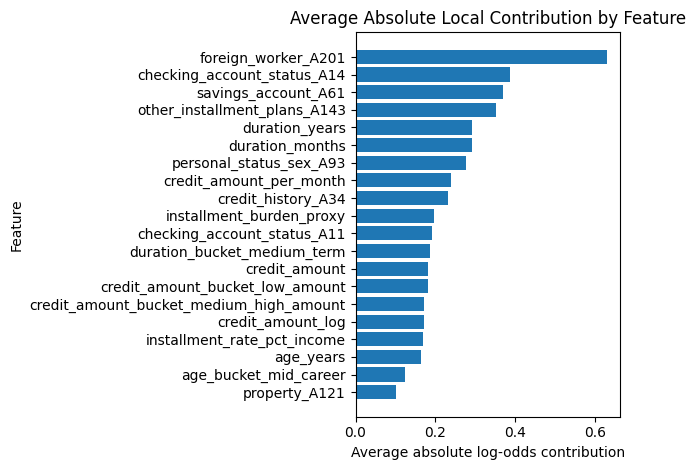

In [29]:

fig, ax = plt.subplots()

plot_contrib = average_contributions.head(20).sort_values("avg_abs_contribution")

ax.barh(plot_contrib["feature"], plot_contrib["avg_abs_contribution"])

ax.set_title("Average Absolute Local Contribution by Feature")
ax.set_xlabel("Average absolute log-odds contribution")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "06_average_local_contributions.png", dpi=150)
plt.show();



## Human-readable risk narrative

This section creates a simple narrative for each borrower in the test sample.

The narrative is deliberately conservative. It does not say that a borrower will default; it explains which model signals are associated with a higher or lower estimated probability of default.


In [30]:

def assign_pd_band(pd_value: float) -> str:
    if pd_value < 0.20:
        return "low estimated credit risk"
    elif pd_value < 0.40:
        return "moderate estimated credit risk"
    elif pd_value < 0.60:
        return "elevated estimated credit risk"
    else:
        return "high estimated credit risk"

def build_risk_narrative(row):
    pd_band = assign_pd_band(row["predicted_pd"])

    narrative = (
        f"The borrower is assigned {pd_band}, with a predicted PD of {row['predicted_pd']:.2%}. "
        f"The strongest upward model signals are: {row['top_positive_contributors']}. "
        f"The strongest downward model signals are: {row['top_negative_contributors']}."
    )

    if "risk_cluster" in row and pd.notna(row["risk_cluster"]):
        narrative += f" The borrower belongs to risk cluster {row['risk_cluster']}."

    if "ensemble_anomaly_flag" in row and pd.notna(row["ensemble_anomaly_flag"]):
        if int(row["ensemble_anomaly_flag"]) == 1:
            narrative += " The borrower is also flagged as an anomalous profile and may deserve additional review."

    return narrative

test_interpretability["risk_narrative"] = test_interpretability.apply(build_risk_narrative, axis=1)

test_interpretability[[
    "predicted_pd",
    "actual_default",
    "risk_narrative",
]].head()


,predicted_pd,actual_default,risk_narrative
30,0.3672,0,The borrower is assigned moderate estimated cr...
128,0.1117,0,The borrower is assigned low estimated credit ...
289,0.8476,1,The borrower is assigned high estimated credit...
216,0.6924,0,The borrower is assigned high estimated credit...
966,0.2095,1,The borrower is assigned moderate estimated cr...



## Save interpretability outputs

This section saves the most important interpretability outputs for reports, README updates, and the future dashboard.


In [31]:

coefficients.to_csv(REPORTS_TABLES / "06_model_coefficients.csv", index=False)
family_importance.to_csv(REPORTS_TABLES / "06_feature_family_importance.csv", index=True)
permutation_importance_df.to_csv(REPORTS_TABLES / "06_permutation_importance.csv", index=False)
average_contributions.to_csv(REPORTS_TABLES / "06_average_local_contributions.csv", index=False)

high_risk_review.to_csv(REPORTS_TABLES / "06_high_risk_borrower_review.csv", index=True)
low_risk_review.to_csv(REPORTS_TABLES / "06_low_risk_borrower_review.csv", index=True)
local_explanations_df.to_csv(REPORTS_TABLES / "06_test_local_explanations.csv", index=True)

if "anomalous_review" in globals():
    anomalous_review.to_csv(REPORTS_TABLES / "06_anomalous_borrower_review.csv", index=True)

if "cluster_explanation_summary" in globals():
    cluster_explanation_summary.to_csv(REPORTS_TABLES / "06_cluster_explanation_summary.csv", index=True)

test_interpretability.to_csv(DATA_PROCESSED / "credit_risk_interpretability_output.csv", index=True)

interpretability_metadata = {
    "model_layer": "model_interpretability",
    "model_type": "LogisticRegression",
    "interpretation_methods": [
        "global_coefficients",
        "odds_ratios",
        "feature_family_importance",
        "permutation_importance",
        "local_log_odds_contributions",
        "borrower_risk_narratives",
    ],
    "train_roc_auc": float(train_auc),
    "test_roc_auc": float(test_auc),
    "n_train_observations": int(len(X_train)),
    "n_test_observations": int(len(X_test)),
    "n_processed_features": int(X_train.shape[1]),
    "intercept": float(intercept),
}

with open(MODELS_DIR / "model_interpretability_metadata.json", "w") as f:
    json.dump(interpretability_metadata, f, indent=4)

print("Saved interpretability tables, borrower explanations, and metadata.")


Saved interpretability tables, borrower explanations, and metadata.



## Analytical conclusions

This notebook added an interpretability layer to the Credit Risk Intelligence Lab.

The main contribution is that the baseline PD model is no longer treated as a black box. Its risk estimates are now explained through global coefficients, feature families, permutation importance, local borrower-level contributions, and readable risk narratives.

Key outputs:

- Global coefficient table with odds ratios and risk direction.
- Higher-risk and lower-risk model signal tables.
- Feature family importance.
- Permutation importance using test ROC-AUC.
- Local log-odds contribution explanations.
- High-risk, low-risk, and anomalous borrower review tables.
- Borrower-level risk narratives.
- Saved interpretability outputs for reporting and dashboard development.

The next notebook should focus on portfolio-level reporting and stress testing:

```text
notebooks/07_portfolio_risk_reporting.ipynb
```

That stage should consolidate PD, clusters, anomalies, exposure, expected loss proxy, and interpretability outputs into portfolio-level risk views.
